<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Deep Learning for Semantic Segmentation — Upsampled Variant</span>

</div>

This notebook implements a **U-Net** model with an **EfficientNet-B3 encoder** pre-trained on ImageNet to segment flood‑affected areas from **8‑channel Synthetic Aperture Radar (SAR)** images. The model distinguishes three classes:

- **Non‑Flooded** (background)
- **Flooded Open** (flood water in open areas)
- **Flooded Urban** (flood water in urban zones)

The key change from the baseline run is **on‑the‑fly spatial upsampling** of every chip before it enters the model. Native UrbanSARFloods chips are **512×512** at roughly **20 m / pixel**; we resample them to push the effective resolution closer to the **5–10 m** range used by higher‑resolution SAR products. The motivation is to give the network finer spatial detail along the boundaries between flooded and built‑up areas — which is where the **Flooded Urban** class is hardest to learn.

<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**          | **Details**                                    |
|--------------------|------------------------------------------------|
| **Course**         | Deep Learning Project                          |
| **Deliverable**    | <span style="color:#E67E22;">**Deliverable 3 – Model Training & Evaluation (Upsampled)**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**   | 28100321 & 28100357                            |

---

In [1]:
!pip install -q segmentation-models-pytorch albumentations tifffile tqdm matplotlib rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.1 MB/s eta 0:00:00


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import rasterio
import cv2
warnings.filterwarnings("ignore")

## <span style="color:#3498DB;">Configuration</span>

A single hyperparameter — `upsample_factor` controls the spatial scaling. Native pixels are ~20 m, so the factor maps directly to an effective resolution.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

upsample_factor = 2
native_chip_size = 512 
upsampled_chip_size = native_chip_size * upsample_factor  # 1024 or 2048

imgsize = 256 * upsample_factor
batch_size = max(1, 16 // (upsample_factor ** 2))   # 4 if 2x, 1 if 4x
num_workers = 4
epochs = 50
lr = 1e-3
in_channels = 8
num_classes = 3
def find_dataset_root(search_root="/kaggle/input", split_file="Train_dataset.txt"):
    for dirpath, dirnames, filenames in os.walk(search_root):
        if split_file in filenames:
            return dirpath
    return None

path = find_dataset_root()
if path is None:
    path = "/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation"
    print(f"WARN: auto-discovery failed, falling back to: {path}")
else:
    print(f"Dataset root detected: {path}")

classes_name = ["Non-Flooded", "Flooded Open", "Flooded Urban"]

print(f"Device: {device}")
print(f"Upsample factor: {upsample_factor}x  ->  chip size {upsampled_chip_size}x{upsampled_chip_size}")
print(f"Train crop size: {imgsize}x{imgsize}")
print(f"Batch size:      {batch_size}")

Dataset root detected: /kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation
Device: cuda
Upsample factor: 2x  ->  chip size 1024x1024
Train crop size: 512x512
Batch size:      4


## <span style="color:#3498DB;">Dataset Preparation</span>


In [ ]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None,
                 upsample_factor=1, target_size=None):
        self.transform = transform
        self.upsample_factor = upsample_factor
        self.target_size = target_size
        self.image_paths = []
        self.mask_paths = []

        split_path = os.path.join(dataset_root, split_file)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f"Split file not found: {split_path}")

        with open(split_path, "r") as f:
            for line in f.readlines():
                raw_path = line.strip()
                if not raw_path:
                    continue
                path_parts = raw_path.split('/')
                clean_base_path = os.path.join(*path_parts[-3:])
                if "GT" in clean_base_path:
                    clean_gt_rel_path = clean_base_path
                    clean_sar_rel_path = clean_base_path.replace("GT", "SAR")
                else:
                    clean_sar_rel_path = clean_base_path
                    clean_gt_rel_path = clean_base_path.replace("SAR", "GT")
                sar_full_path = os.path.join(dataset_root, clean_sar_rel_path)
                gt_full_path = os.path.join(dataset_root, clean_gt_rel_path)

                num_repeats = 1
                if "Train" in split_file and "03_FU" in clean_base_path:
                    num_repeats = 4   # inflate Flooded Urban
                for _ in range(num_repeats):
                    self.image_paths.append(sar_full_path)
                    self.mask_paths.append(gt_full_path)

    def __len__(self):
        return len(self.image_paths)

    def _resize_image(self, image_hwc):
        """Bicubic upsample for SAR bands. image_hwc shape: (H, W, C)."""
        if self.target_size is not None:
            new_h = new_w = self.target_size
        elif self.upsample_factor != 1:
            h, w = image_hwc.shape[:2]
            new_h, new_w = h * self.upsample_factor, w * self.upsample_factor
        else:
            return image_hwc
        c = image_hwc.shape[2]
        out = np.empty((new_h, new_w, c), dtype=image_hwc.dtype)
        for i in range(c):
            out[:, :, i] = cv2.resize(image_hwc[:, :, i], (new_w, new_h),
                                      interpolation=cv2.INTER_CUBIC)
        return out

    def _resize_mask(self, mask_hw):
        """Nearest-neighbour upsample for the categorical mask."""
        if self.target_size is not None:
            new_h = new_w = self.target_size
        elif self.upsample_factor != 1:
            h, w = mask_hw.shape
            new_h, new_w = h * self.upsample_factor, w * self.upsample_factor
        else:
            return mask_hw
        return cv2.resize(mask_hw.astype(np.int32), (new_w, new_h),
                          interpolation=cv2.INTER_NEAREST).astype(np.int64)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32)         # (C, H, W)
        with rasterio.open(self.mask_paths[index]) as src:
            mask = src.read(1).astype(np.int64)           # (H, W)

        mask[mask < 0] = 0
        mask[mask >= num_classes] = 0

        image = np.transpose(image, (1, 2, 0))
        image = self._resize_image(image)
        mask = self._resize_mask(mask)
        for c in range(in_channels):
            c_min = image[:, :, c].min()
            c_max = image[:, :, c].max()
            if c_max > c_min:
                image[:, :, c] = (image[:, :, c] - c_min) / (c_max - c_min)
            else:
                image[:, :, c] = 0.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask

In [ ]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(
        path, "Train_dataset.txt",
        transform=train_transform,
        upsample_factor=upsample_factor,
    )
    val_dataset = UrbanSARDataset(
        path, "Valid_dataset.txt",
        transform=val_transform,
        upsample_factor=upsample_factor,
    )
except Exception as e:
    print(f"Dataset not loaded: {e}")
    raise

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

sample_img, sample_mask = train_dataset[0]
print(f"Sample image tensor: {sample_img.shape}, dtype={sample_img.dtype}")
print(f"Sample mask  tensor: {sample_mask.shape}, dtype={sample_mask.dtype}")
print(f"Mask unique values:  {torch.unique(sample_mask).tolist()}")

Train samples: 5914
Val samples:   1970
Sample image tensor: torch.Size([8, 512, 512]), dtype=torch.float32
Sample mask  tensor: torch.Size([512, 512]), dtype=torch.int64
Mask unique values:  [0]


## <span style="color:#3498DB;">2. Model Architecture</span>

We employ a **U‑Net** with an **EfficientNet‑B3 encoder** pre‑trained on ImageNet, plus **SCSE attention** in the decoder. The encoder extracts multi‑scale features, while the decoder reconstructs the segmentation mask.

```python
smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=8,
    classes=3,
    decoder_attention_type="scse"
)
```

The backbone is identical to the non‑upsampled baseline — the only thing changing between runs is the input resolution, so any improvement (or regression) is directly attributable to upsampling.

In [6]:
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=in_channels,
    classes=num_classes,
    decoder_attention_type="scse"
).to(device)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [7]:
class_weights = torch.tensor([0.1, 0.4, 0.5]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

In [8]:
def compute_metrics(preds, targets, num_classes):
    """Per-class IoU and F1.

    Convention for empty classes (matches torchmetrics / most seg papers):
      - class absent from BOTH preds and targets -> score = 1.0 (perfect, nothing to get wrong)
      - class present in only one of them        -> score = 0.0
    This keeps every returned value a finite number, so downstream means never produce NaN.
    """
    preds = torch.argmax(preds, dim=1).view(-1)
    targets = targets.view(-1)
    ious = []
    f1s = []
    eps = 1e-7
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = targets == cls
        intersection = (pred_inds & target_inds).sum().float()
        pred_sum = pred_inds.sum().float()
        target_sum = target_inds.sum().float()
        union = pred_sum + target_sum - intersection

        if pred_sum == 0 and target_sum == 0:
            ious.append(1.0)
            f1s.append(1.0)
        else:
            ious.append((intersection / (union + eps)).item())
            f1s.append(((2.0 * intersection) / (pred_sum + target_sum + eps)).item())
    return ious, f1s

## <span style="color:#3498DB;">Training Loop</span>

The model is trained for **30 epochs**. Each epoch:

- **Training phase**: forward pass, loss computation, backpropagation (with gradient scaling if AMP is used).
- **Validation phase**: no gradients, compute loss and metrics.

### Evaluation Metrics:
- **IoU** (Intersection over Union) per class, then mean IoU (mIoU).
- **F1‑score** per class, then mean F1 (mF1).
- **Urban F1‑score** (class 2) – most important for the application.

### NaN‑Free Reporting:
- When a class is absent from both predictions and targets in a batch, IoU and F1 are defined as **1.0** (perfect — nothing to get wrong), following the torchmetrics convention.
- Training and validation losses skip any non‑finite value (rare, but possible under AMP), so the printed averages are always well‑defined.
- Checkpoints are only saved on a finite improved validation loss.

In [ ]:
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_batches = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)
    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                preds = model(images)
                loss = loss_fn(preds, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()

        loss_val = loss.item()
        if np.isfinite(loss_val):
            train_loss += loss_val
            train_batches += 1
        train_loop.set_postfix(loss=f"{loss_val:.4f}")
    avg_train_loss = train_loss / max(train_batches, 1)

    model.eval()
    val_loss = 0.0
    val_batches = 0
    val_ious = []
    val_f1s = []
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    preds = model(images)
                    loss = loss_fn(preds, masks)
            else:
                preds = model(images)
                loss = loss_fn(preds, masks)
            loss_val = loss.item()
            if np.isfinite(loss_val):
                val_loss += loss_val
                val_batches += 1
            batch_ious, batch_f1s = compute_metrics(preds, masks, num_classes)
            val_ious.append(batch_ious)
            val_f1s.append(batch_f1s)

    avg_val_loss = val_loss / max(val_batches, 1)
    epoch_ious = np.mean(np.array(val_ious), axis=0)
    epoch_f1s = np.mean(np.array(val_f1s), axis=0)
    miou = float(np.mean(epoch_ious))
    mf1 = float(np.mean(epoch_f1s))
    urban_f1 = float(epoch_f1s[2])
    scheduler.step()
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
        f"mIoU: {miou:.4f} | mF1: {mf1:.4f} | Urban F1: {urban_f1:.4f} | "
        f"Per-class IoU: {[f'{x:.3f}' for x in epoch_ious]}"
    )

    if np.isfinite(avg_val_loss) and avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), f"unet_effb3_upsample{upsample_factor}x_best.pth")

torch.save(model.state_dict(), f"unet_effb3_upsample{upsample_factor}x_final.pth")

Epoch 01/50 | Train Loss: 0.1760 | Val Loss: 0.0927 | mIoU: 0.8796 | mF1: 0.8920 | Urban F1: 0.9067 | Per-class IoU: ['0.988', '0.745', '0.907']


Epoch 02/50 | Train Loss: 0.1239 | Val Loss: 0.5239 | mIoU: 0.7104 | mF1: 0.7193 | Urban F1: 0.8560 | Per-class IoU: ['0.970', '0.305', '0.856']


Epoch 03/50 | Train Loss: 0.1180 | Val Loss: 0.0917 | mIoU: 0.7806 | mF1: 0.7933 | Urban F1: 0.9067 | Per-class IoU: ['0.987', '0.448', '0.907']


Epoch 04/50 | Train Loss: 0.1139 | Val Loss: 0.0723 | mIoU: 0.8154 | mF1: 0.8289 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.554', '0.907']


Epoch 05/50 | Train Loss: 0.1095 | Val Loss: 0.0723 | mIoU: 0.8717 | mF1: 0.8845 | Urban F1: 0.9067 | Per-class IoU: ['0.990', '0.718', '0.907']


...

Epoch 46/50 | Train Loss: 0.0000 | Val Loss: 0.0000 | mIoU: 0.8759 | mF1: 0.8783 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.736', '0.907']


Epoch 47/50 | Train Loss: 0.0000 | Val Loss: 0.0000 | mIoU: 0.8759 | mF1: 0.8783 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.736', '0.907']


Epoch 48/50 | Train Loss: 0.0000 | Val Loss: 0.0000 | mIoU: 0.8759 | mF1: 0.8783 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.736', '0.907']


Epoch 49/50 | Train Loss: 0.0000 | Val Loss: 0.0000 | mIoU: 0.8759 | mF1: 0.8783 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.736', '0.907']


Epoch 50/50 | Train Loss: 0.0000 | Val Loss: 0.0000 | mIoU: 0.8759 | mF1: 0.8783 | Urban F1: 0.9067 | Per-class IoU: ['0.985', '0.736', '0.907']


## <span style="color:#3498DB;">Results & Visualization</span>

After training, we load the best model and visualise predictions on validation samples. For each sample:

- **Left**: SAR image (first channel, upsampled)
- **Middle**: Ground truth mask (0: Non‑Flooded, 1: Flooded Open, 2: Flooded Urban)
- **Right**: Model prediction


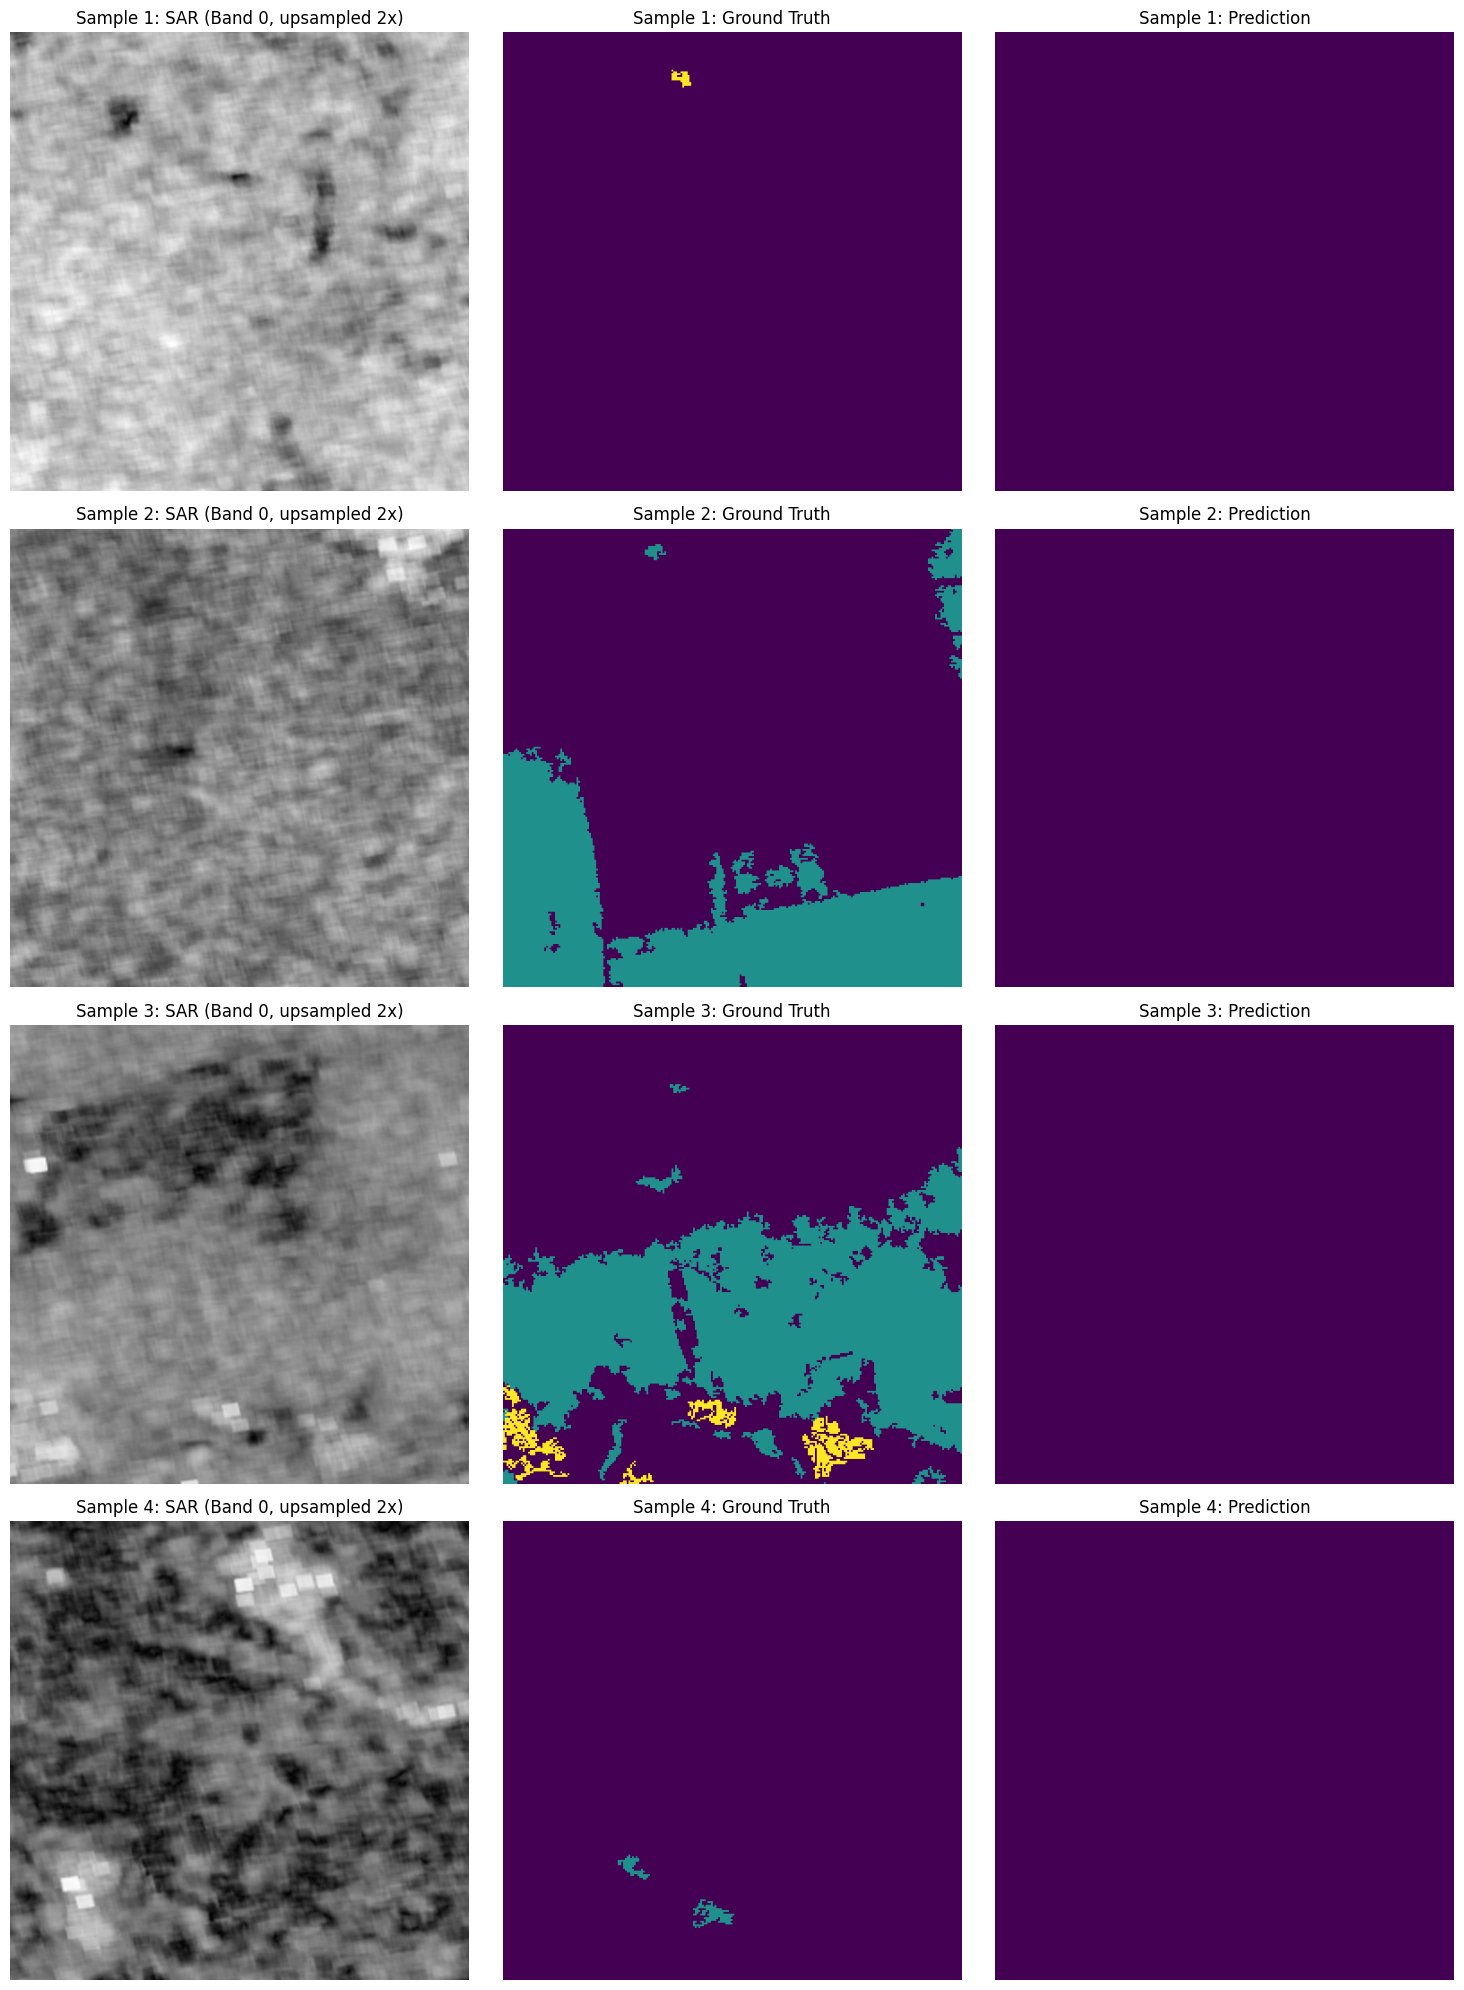

In [10]:
model.load_state_dict(torch.load(f"unet_effb3_upsample{upsample_factor}x_best.pth"))
model.eval()

val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast("cuda"):
            raw_preds = model(val_images)
    else:
        raw_preds = model(val_images)
pred_masks = torch.argmax(raw_preds, dim=1).cpu().numpy()
val_images_cpu = val_images.cpu().numpy()
val_masks_cpu = val_masks.cpu().numpy()

num_samples = min(4, batch_size if batch_size > 1 else 1)
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
if num_samples == 1:
    axes = np.expand_dims(axes, 0)

for i in range(num_samples):
    axes[i, 0].imshow(val_images_cpu[i, 0], cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1}: SAR (Band 0, upsampled {upsample_factor}x)")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(val_masks_cpu[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(pred_masks[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 2].set_title(f"Sample {i+1}: Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()